In [22]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_ROOT = "/content/drive/MyDrive/maxrl_lunar_safe"
os.makedirs(SAVE_ROOT, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
!pip install -q gymnasium[classic-control]
!pip install -q gymnasium[box2d]
!pip install -q swig
!pip install -q torch numpy matplotlib pandas tqdm

In [23]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import gymnasium as gym

import torch
import torch.nn as nn
import torch.optim as optim

In [33]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

ENV_NAME = "LunarLander-v3"   # 안 되면 "LunarLander-v2"로 바꿔봐
SEED = 0

N_ITERS = 800
BATCH_SIZE = 32
LR = 1e-3
GAMMA = 0.99
ENTROPY_COEF = 0.001

SUCCESS_THRESHOLD = 200.0

Device: cuda


# cell 4 policy network

In [34]:
class PolicyNet(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, action_dim),
        )

    def forward(self, x):
        return self.net(x)

    def get_action_batch(self, obs_batch):
        obs = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
        logits = self.forward(obs)
        dist = torch.distributions.Categorical(logits=logits)
        actions = dist.sample()
        log_probs = dist.log_prob(actions)
        entropies = dist.entropy()
        return actions.cpu().numpy(), log_probs, entropies

    def get_action(self, obs):
        actions, log_probs, entropies = self.get_action_batch(obs[None, :])
        return int(actions[0]), log_probs[0], entropies[0]

cell 5: Rollout

In [35]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def discounted_return(rewards, gamma=0.99):
    G = 0.0
    for r in reversed(rewards):
        G = r + gamma * G
    return G


def make_env(env_name, seed, idx):
    def thunk():
        env = gym.make(env_name)
        env.reset(seed=seed + idx)
        return env
    return thunk


def collect_parallel_episodes(envs, policy, gamma=0.99, max_steps=500):
    n_envs = envs.num_envs
    obs, _ = envs.reset()

    active = np.ones(n_envs, dtype=bool)

    log_probs_list = [[] for _ in range(n_envs)]
    entropies_list = [[] for _ in range(n_envs)]

    raw_returns = np.zeros(n_envs, dtype=np.float32)
    discounted_returns = np.zeros(n_envs, dtype=np.float32)
    discount_factors = np.ones(n_envs, dtype=np.float32)
    lengths = np.zeros(n_envs, dtype=np.int32)

    for _ in range(max_steps):
        actions, log_probs, entropies = policy.get_action_batch(obs)

        next_obs, rewards, terminated, truncated, _ = envs.step(actions)
        dones = np.logical_or(terminated, truncated)

        for i in range(n_envs):
            if active[i]:
                log_probs_list[i].append(log_probs[i])
                entropies_list[i].append(entropies[i])

                raw_returns[i] += rewards[i]
                discounted_returns[i] += discount_factors[i] * rewards[i]
                discount_factors[i] *= gamma
                lengths[i] += 1

                if dones[i]:
                    active[i] = False

        obs = next_obs

        if not active.any():
            break

    episodes = []
    for i in range(n_envs):
        episodes.append({
            "log_probs": torch.stack(log_probs_list[i]),
            "entropies": torch.stack(entropies_list[i]),
            "return": float(raw_returns[i]),
            "discounted_return": float(discounted_returns[i]),
            "success": float(raw_returns[i] >= SUCCESS_THRESHOLD),
            "length": int(lengths[i]),
        })

    return episodes

# 6. Weight Calculation

In [36]:
def compute_weights(returns, successes, method):
    """
    returns: torch.Tensor, shape (B,)
    successes: torch.Tensor, shape (B,)
    """

    if method == "reinforce":
        # Standard REINFORCE: absolute return weighting
        weights = returns

    elif method == "binary_maxrl":
        # Binary MaxRL: only successful trajectories are used
        K = successes.sum()
        if K.item() > 0:
            weights = successes / (K + 1e-8)
        else:
            weights = torch.zeros_like(successes)

    elif method == "continuous_maxrl":
        # Continuous MaxRL: reward-mass normalization
        R = returns.clone()

        # shift to nonnegative
        R = R - R.min()
        R = torch.clamp(R, min=0.0)

        denom = R.sum() + 1e-8
        weights = R / denom

    else:
        raise ValueError(f"Unknown method: {method}")

    return weights

# 7. Training

In [37]:
def train_method(
    env_name="LunarLander-v3",
    method="continuous_maxrl",
    n_iters=800,
    batch_size=32,
    lr=1e-3,
    gamma=0.99,
    entropy_coef=0.0,
    seed=0,
    max_steps=500,
):
    set_seed(seed)

    temp_env = gym.make(env_name)
    obs_dim = temp_env.observation_space.shape[0]
    action_dim = temp_env.action_space.n
    temp_env.close()

    envs = gym.vector.AsyncVectorEnv(
        [make_env(env_name, seed, i) for i in range(batch_size)]
    )

    policy = PolicyNet(obs_dim, action_dim).to(DEVICE)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    history = {
        "avg_return": [],
        "success_rate": [],
        "avg_length": [],
        "loss": [],
        "entropy": [],
    }

    run_name = f"{method}_entropy{entropy_coef}_seed{seed}"
    run_dir = os.path.join(SAVE_ROOT, run_name)
    os.makedirs(run_dir, exist_ok=True)

    for it in tqdm(range(n_iters), desc=f"{method}, entropy={entropy_coef}"):
        episodes = collect_parallel_episodes(
            envs,
            policy,
            gamma=gamma,
            max_steps=max_steps,
        )

        returns = torch.tensor(
            [ep["discounted_return"] for ep in episodes],
            dtype=torch.float32,
            device=DEVICE,
        )

        raw_returns = torch.tensor(
            [ep["return"] for ep in episodes],
            dtype=torch.float32,
            device=DEVICE,
        )

        successes = torch.tensor(
            [ep["success"] for ep in episodes],
            dtype=torch.float32,
            device=DEVICE,
        )

        weights = compute_weights(returns, successes, method=method)

        policy_loss = 0.0
        entropy_bonus = 0.0

        for w, ep in zip(weights, episodes):
            log_prob_sum = ep["log_probs"].sum()
            entropy_sum = ep["entropies"].sum()

            policy_loss += -w.detach() * log_prob_sum
            entropy_bonus += entropy_sum

        policy_loss = policy_loss / batch_size
        entropy_bonus = entropy_bonus / batch_size

        loss = policy_loss - entropy_coef * entropy_bonus

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        optimizer.step()

        history["avg_return"].append(raw_returns.mean().item())
        history["success_rate"].append(successes.mean().item())
        history["avg_length"].append(np.mean([ep["length"] for ep in episodes]))
        history["loss"].append(loss.item())
        history["entropy"].append(entropy_bonus.item())

        if (it + 1) % 50 == 0:
            print(
                f"Iter {it+1:4d} | "
                f"Return {history['avg_return'][-1]:8.2f} | "
                f"Success {history['success_rate'][-1]:.3f} | "
                f"Entropy {history['entropy'][-1]:.3f}"
            )

            pd.DataFrame(history).to_csv(os.path.join(run_dir, "history.csv"), index=False)

            ckpt = {
                "iteration": it + 1,
                "model_state_dict": policy.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "history": history,
                "method": method,
                "entropy_coef": entropy_coef,
                "seed": seed,
            }

            torch.save(ckpt, os.path.join(run_dir, f"checkpoint_iter_{it+1}.pt"))
            torch.save(ckpt, os.path.join(run_dir, "latest.pt"))

    envs.close()

    pd.DataFrame(history).to_csv(os.path.join(run_dir, "history_final.csv"), index=False)
    torch.save(policy.state_dict(), os.path.join(run_dir, "policy_final.pt"))

    return policy, pd.DataFrame(history)

# 8. Experiments

In [19]:
experiments = {}

configs = [
    ("REINFORCE", "reinforce", 0.0),
    ("Binary MaxRL", "binary_maxrl", 0.0),
    ("Continuous MaxRL", "continuous_maxrl", 0.0),
    ("Entropy Continuous MaxRL", "continuous_maxrl", ENTROPY_COEF),
]

for name, method, ent_coef in configs:
    policy, hist = train_method(
        env_name=ENV_NAME,
        method=method,
        n_iters=N_ITERS,
        batch_size=BATCH_SIZE,
        lr=LR,
        gamma=GAMMA,
        entropy_coef=ent_coef,
        seed=SEED,
    )
    experiments[name] = {
        "policy": policy,
        "history": hist,
    }

reinforce, entropy=0.0:   0%|          | 0/800 [00:00<?, ?it/s]

Iter   50 | Return   -77.12 | Success 0.000 | Entropy 139.113
Iter  100 | Return    18.22 | Success 0.000 | Entropy 455.357
Iter  150 | Return   -24.61 | Success 0.000 | Entropy 455.825
Iter  200 | Return    58.70 | Success 0.000 | Entropy 492.685
Iter  250 | Return    48.15 | Success 0.000 | Entropy 427.130
Iter  300 | Return    59.34 | Success 0.000 | Entropy 437.407
Iter  350 | Return    37.85 | Success 0.000 | Entropy 468.790
Iter  400 | Return    15.66 | Success 0.000 | Entropy 360.753
Iter  450 | Return    -7.74 | Success 0.000 | Entropy 352.890
Iter  500 | Return    67.28 | Success 0.000 | Entropy 423.543
Iter  550 | Return    60.26 | Success 0.000 | Entropy 421.428
Iter  600 | Return    49.05 | Success 0.000 | Entropy 388.247
Iter  650 | Return    33.56 | Success 0.000 | Entropy 456.809
Iter  700 | Return    83.72 | Success 0.000 | Entropy 442.840
Iter  750 | Return    75.63 | Success 0.000 | Entropy 380.683
Iter  800 | Return    72.45 | Success 0.000 | Entropy 400.899


binary_maxrl, entropy=0.0:   0%|          | 0/800 [00:00<?, ?it/s]

Iter   50 | Return  -151.27 | Success 0.000 | Entropy 125.498
Iter  100 | Return  -213.36 | Success 0.000 | Entropy 141.637
Iter  150 | Return  -202.97 | Success 0.000 | Entropy 128.261
Iter  200 | Return  -196.02 | Success 0.000 | Entropy 130.136
Iter  250 | Return  -171.21 | Success 0.000 | Entropy 125.091
Iter  300 | Return  -173.19 | Success 0.000 | Entropy 126.284
Iter  350 | Return  -183.87 | Success 0.000 | Entropy 124.367
Iter  400 | Return  -152.75 | Success 0.000 | Entropy 139.814
Iter  450 | Return  -160.88 | Success 0.000 | Entropy 123.777
Iter  500 | Return  -148.70 | Success 0.000 | Entropy 120.227
Iter  550 | Return  -183.81 | Success 0.000 | Entropy 124.083
Iter  600 | Return  -216.06 | Success 0.000 | Entropy 127.878
Iter  650 | Return  -197.41 | Success 0.000 | Entropy 123.859
Iter  700 | Return  -164.92 | Success 0.000 | Entropy 121.783
Iter  750 | Return  -196.89 | Success 0.000 | Entropy 135.929
Iter  800 | Return  -169.71 | Success 0.000 | Entropy 122.911


continuous_maxrl, entropy=0.0:   0%|          | 0/800 [00:00<?, ?it/s]

Iter   50 | Return   -57.56 | Success 0.000 | Entropy 138.014
Iter  100 | Return   -73.19 | Success 0.000 | Entropy 434.992
Iter  150 | Return   -62.47 | Success 0.000 | Entropy 468.554
Iter  200 | Return    44.22 | Success 0.000 | Entropy 462.094
Iter  250 | Return    38.36 | Success 0.000 | Entropy 412.661
Iter  300 | Return    43.00 | Success 0.000 | Entropy 439.293
Iter  350 | Return    40.19 | Success 0.000 | Entropy 311.400
Iter  400 | Return    51.05 | Success 0.000 | Entropy 358.581
Iter  450 | Return    38.43 | Success 0.000 | Entropy 415.556
Iter  500 | Return    45.76 | Success 0.000 | Entropy 448.365
Iter  550 | Return    68.14 | Success 0.000 | Entropy 414.233
Iter  600 | Return    79.57 | Success 0.000 | Entropy 426.610
Iter  650 | Return    88.56 | Success 0.000 | Entropy 457.877
Iter  700 | Return    69.33 | Success 0.000 | Entropy 487.530
Iter  750 | Return    69.89 | Success 0.000 | Entropy 395.274
Iter  800 | Return    89.73 | Success 0.000 | Entropy 425.839


continuous_maxrl, entropy=0.001:   0%|          | 0/800 [00:00<?, ?it/s]

Iter   50 | Return  -103.63 | Success 0.000 | Entropy 115.599
Iter  100 | Return   -52.90 | Success 0.000 | Entropy 146.384
Iter  150 | Return    -0.40 | Success 0.000 | Entropy 145.491
Iter  200 | Return    16.89 | Success 0.000 | Entropy 284.909
Iter  250 | Return     3.41 | Success 0.000 | Entropy 168.176
Iter  300 | Return     2.05 | Success 0.000 | Entropy 162.222
Iter  350 | Return    17.36 | Success 0.000 | Entropy 182.035
Iter  400 | Return   -20.48 | Success 0.000 | Entropy 112.531
Iter  450 | Return     5.80 | Success 0.000 | Entropy 151.157
Iter  500 | Return     6.78 | Success 0.000 | Entropy 176.430
Iter  550 | Return   -11.98 | Success 0.000 | Entropy 146.334
Iter  600 | Return   -18.11 | Success 0.000 | Entropy 132.903
Iter  650 | Return   -27.63 | Success 0.000 | Entropy 117.279
Iter  700 | Return     1.10 | Success 0.000 | Entropy 151.713
Iter  750 | Return   -13.91 | Success 0.000 | Entropy 135.092
Iter  800 | Return    -6.75 | Success 0.000 | Entropy 149.025


# 9 Plot

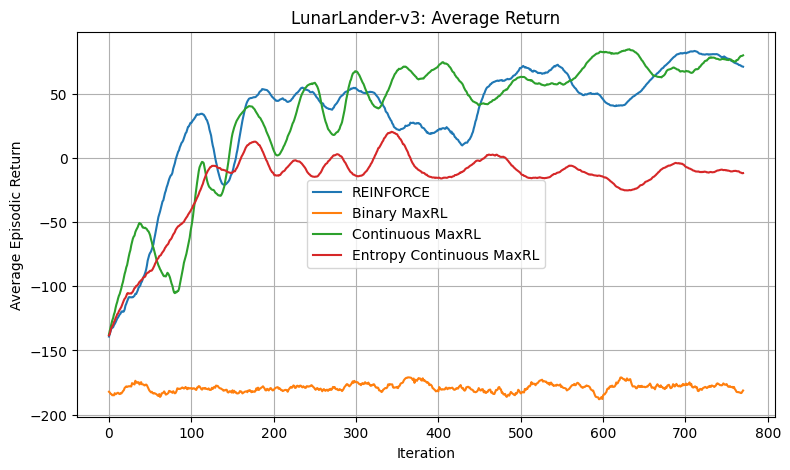

<Figure size 640x480 with 0 Axes>

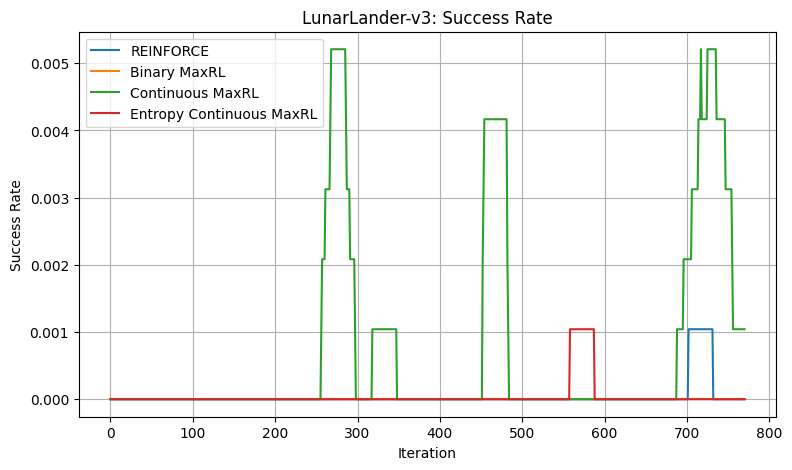

<Figure size 640x480 with 0 Axes>

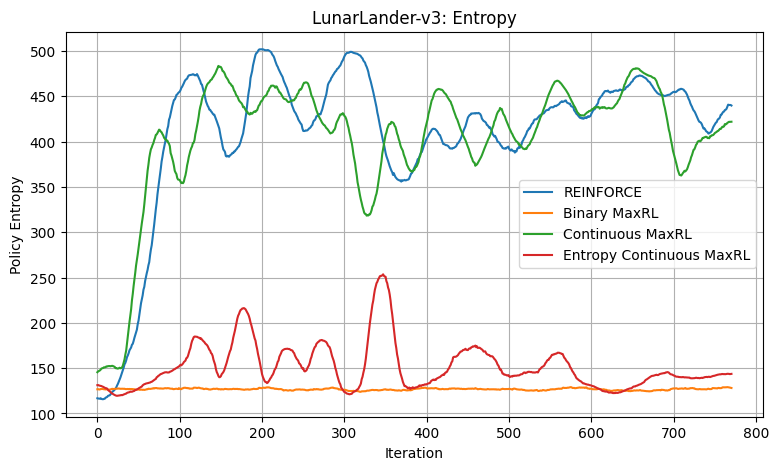

<Figure size 640x480 with 0 Axes>

In [20]:
def moving_average(x, window=30):
    x = np.asarray(x)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")


plt.figure(figsize=(9, 5))
for name, obj in experiments.items():
    y = moving_average(obj["history"]["avg_return"], window=30)
    plt.plot(y, label=name)
plt.xlabel("Iteration")
plt.ylabel("Average Episodic Return")
plt.title(f"{ENV_NAME}: Average Return")
plt.legend()
plt.grid(True)
FIG_DIR = "/content/drive/MyDrive/maxrl_lunar_safe/figures"
os.makedirs(FIG_DIR, exist_ok=True)
plt.show()
plt.savefig(os.path.join(FIG_DIR, "average_return.png"), dpi=300, bbox_inches="tight")


plt.figure(figsize=(9, 5))
for name, obj in experiments.items():
    y = moving_average(obj["history"]["success_rate"], window=30)
    plt.plot(y, label=name)
plt.xlabel("Iteration")
plt.ylabel("Success Rate")
plt.title(f"{ENV_NAME}: Success Rate")
plt.legend()
plt.grid(True)
FIG_DIR = "/content/drive/MyDrive/maxrl_lunar_safe/figures"
os.makedirs(FIG_DIR, exist_ok=True)
plt.show()
plt.savefig(os.path.join(FIG_DIR, "average_return.png"), dpi=300, bbox_inches="tight")


plt.figure(figsize=(9, 5))
for name, obj in experiments.items():
    y = moving_average(obj["history"]["entropy"], window=30)
    plt.plot(y, label=name)
plt.xlabel("Iteration")
plt.ylabel("Policy Entropy")
plt.title(f"{ENV_NAME}: Entropy")
plt.legend()
plt.grid(True)
FIG_DIR = "/content/drive/MyDrive/maxrl_lunar_safe/figures"
os.makedirs(FIG_DIR, exist_ok=True)
plt.show()
plt.savefig(os.path.join(FIG_DIR, "entropy.png"), dpi=300, bbox_inches="tight")

# 10. Result save

Saved final CSV/model files to: /content/drive/MyDrive/maxrl_lunar_safe/final_results


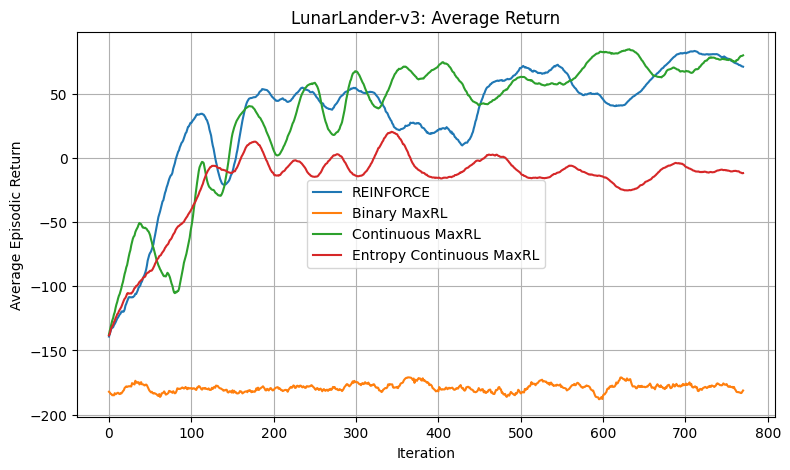

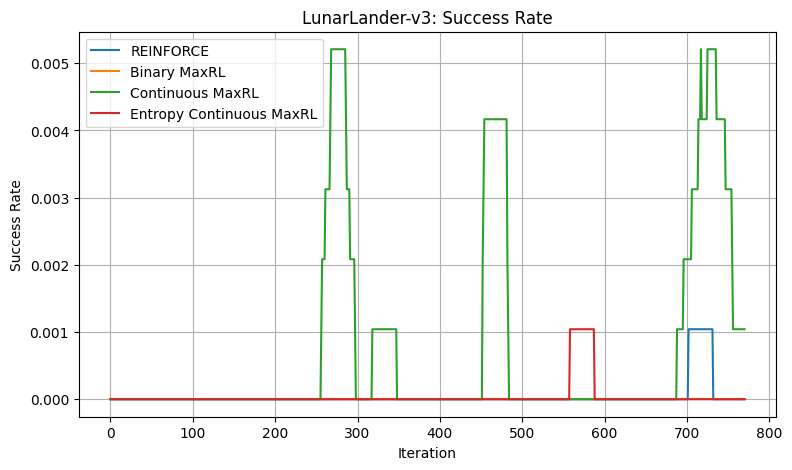

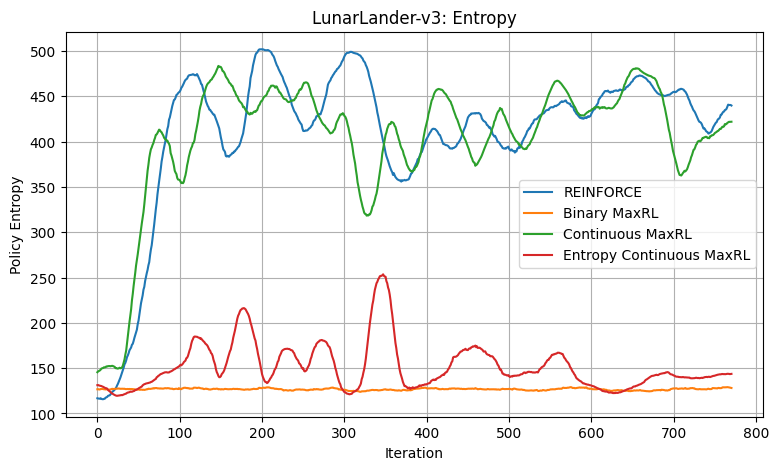

Saved figures to: /content/drive/MyDrive/maxrl_lunar_safe/figures
Recording video for: reinforce


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/maxrl_lunar_safe/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Recording video for: binary_maxrl


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/maxrl_lunar_safe/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Recording video for: continuous_maxrl
Recording video for: entropy_continuous_maxrl
Saved videos to: /content/drive/MyDrive/maxrl_lunar_safe/videos
Created zip: /content/maxrl_lunar_safe.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import os
import shutil
from google.colab import files
import gymnasium as gym
from gymnasium.wrappers import RecordVideo

# ===== unified save paths =====
SAVE_ROOT = "/content/drive/MyDrive/maxrl_lunar_safe"
FINAL_DIR = os.path.join(SAVE_ROOT, "final_results")
VIDEO_DIR = os.path.join(SAVE_ROOT, "videos")
FIG_DIR = os.path.join(SAVE_ROOT, "figures")

os.makedirs(FINAL_DIR, exist_ok=True)
os.makedirs(VIDEO_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# ===== save csv + policies =====
for name, obj in experiments.items():
    safe_name = name.replace(" ", "_").lower()
    obj["history"].to_csv(os.path.join(FINAL_DIR, f"{safe_name}.csv"), index=False)
    torch.save(obj["policy"].state_dict(), os.path.join(FINAL_DIR, f"{safe_name}_policy.pt"))

print("Saved final CSV/model files to:", FINAL_DIR)

# ===== save figures =====
plt.figure(figsize=(9, 5))
for name, obj in experiments.items():
    y = moving_average(obj["history"]["avg_return"], window=30)
    plt.plot(y, label=name)
plt.xlabel("Iteration")
plt.ylabel("Average Episodic Return")
plt.title(f"{ENV_NAME}: Average Return")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, "average_return.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
for name, obj in experiments.items():
    y = moving_average(obj["history"]["success_rate"], window=30)
    plt.plot(y, label=name)
plt.xlabel("Iteration")
plt.ylabel("Success Rate")
plt.title(f"{ENV_NAME}: Success Rate")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, "success_rate.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
for name, obj in experiments.items():
    y = moving_average(obj["history"]["entropy"], window=30)
    plt.plot(y, label=name)
plt.xlabel("Iteration")
plt.ylabel("Policy Entropy")
plt.title(f"{ENV_NAME}: Entropy")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, "entropy.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures to:", FIG_DIR)

# ===== record videos =====
def record_video(env_name, policy, name, max_steps=1000):
    env = gym.make(env_name, render_mode="rgb_array")
    env = RecordVideo(
        env,
        video_folder=VIDEO_DIR,
        name_prefix=name,
        episode_trigger=lambda episode_id: True
    )

    obs, _ = env.reset()
    done = False
    steps = 0

    while not done and steps < max_steps:
        action, _, _ = policy.get_action(obs)
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        steps += 1

    env.close()

for name, obj in experiments.items():
    safe_name = name.replace(" ", "_").lower()
    print("Recording video for:", safe_name)
    record_video(ENV_NAME, obj["policy"], safe_name)

print("Saved videos to:", VIDEO_DIR)

# ===== zip everything and download =====
ZIP_BASE = "/content/maxrl_lunar_safe"
ZIP_PATH = ZIP_BASE + ".zip"

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

shutil.make_archive(ZIP_BASE, "zip", SAVE_ROOT)

print("Created zip:", ZIP_PATH)
files.download(ZIP_PATH)

In [38]:
entropy_sweep = [0.00005, 0.0001, 0.0003, 0.0005]

In [43]:
MAX_STEPS = 500
experiments = {}
for ent_coef in entropy_sweep:
    name = f"Entropy Continuous MaxRL {ent_coef}"

    policy, hist = train_method(
        env_name=ENV_NAME,
        method="continuous_maxrl",
        n_iters=N_ITERS,
        batch_size=BATCH_SIZE,
        lr=LR,
        gamma=GAMMA,
        entropy_coef=ent_coef,
        seed=SEED,
        max_steps=MAX_STEPS,
    )

    experiments[name] = {
        "policy": policy,
        "history": hist,
    }

print("Entropy sweep done.")

continuous_maxrl, entropy=5e-05:   0%|          | 0/800 [00:00<?, ?it/s]

Iter   50 | Return   -76.58 | Success 0.000 | Entropy 118.962
Iter  100 | Return    -9.71 | Success 0.000 | Entropy 318.750
Iter  150 | Return    15.63 | Success 0.000 | Entropy 254.297
Iter  200 | Return    38.61 | Success 0.094 | Entropy 215.335
Iter  250 | Return    69.15 | Success 0.156 | Entropy 388.271
Iter  300 | Return    52.98 | Success 0.000 | Entropy 474.489
Iter  350 | Return    62.93 | Success 0.000 | Entropy 422.162
Iter  400 | Return   105.35 | Success 0.344 | Entropy 252.216
Iter  450 | Return    94.40 | Success 0.000 | Entropy 400.153
Iter  500 | Return   100.38 | Success 0.000 | Entropy 381.775
Iter  550 | Return    81.92 | Success 0.031 | Entropy 438.775
Iter  600 | Return    91.23 | Success 0.000 | Entropy 395.981
Iter  650 | Return   113.89 | Success 0.000 | Entropy 396.739
Iter  700 | Return    62.81 | Success 0.000 | Entropy 460.623
Iter  750 | Return    97.62 | Success 0.000 | Entropy 394.795
Iter  800 | Return    63.19 | Success 0.000 | Entropy 368.506


continuous_maxrl, entropy=0.0001:   0%|          | 0/800 [00:00<?, ?it/s]

Iter   50 | Return   -66.15 | Success 0.000 | Entropy 125.630
Iter  100 | Return   -30.21 | Success 0.000 | Entropy 417.446
Iter  150 | Return   -62.50 | Success 0.000 | Entropy 352.362
Iter  200 | Return    41.77 | Success 0.000 | Entropy 372.152
Iter  250 | Return    29.67 | Success 0.000 | Entropy 363.289
Iter  300 | Return    47.94 | Success 0.000 | Entropy 428.649
Iter  350 | Return    24.56 | Success 0.000 | Entropy 425.916
Iter  400 | Return    44.63 | Success 0.000 | Entropy 237.565
Iter  450 | Return    52.19 | Success 0.000 | Entropy 437.199
Iter  500 | Return    57.14 | Success 0.000 | Entropy 430.715
Iter  550 | Return    89.54 | Success 0.000 | Entropy 440.377
Iter  600 | Return    81.10 | Success 0.000 | Entropy 417.612
Iter  650 | Return    38.15 | Success 0.000 | Entropy 344.063
Iter  700 | Return    42.87 | Success 0.000 | Entropy 390.412
Iter  750 | Return    32.77 | Success 0.000 | Entropy 214.904
Iter  800 | Return    62.59 | Success 0.000 | Entropy 392.046


continuous_maxrl, entropy=0.0003:   0%|          | 0/800 [00:00<?, ?it/s]

Iter   50 | Return  -105.57 | Success 0.000 | Entropy 120.980
Iter  100 | Return   -35.61 | Success 0.000 | Entropy 171.833
Iter  150 | Return     6.17 | Success 0.000 | Entropy 224.879
Iter  200 | Return    52.27 | Success 0.000 | Entropy 280.032
Iter  250 | Return    48.85 | Success 0.000 | Entropy 296.537
Iter  300 | Return    78.86 | Success 0.000 | Entropy 354.869
Iter  350 | Return    21.34 | Success 0.000 | Entropy 128.588
Iter  400 | Return    49.23 | Success 0.000 | Entropy 345.435
Iter  450 | Return    48.27 | Success 0.000 | Entropy 227.364
Iter  500 | Return    40.71 | Success 0.000 | Entropy 290.514
Iter  550 | Return    71.09 | Success 0.000 | Entropy 364.887
Iter  600 | Return    62.66 | Success 0.000 | Entropy 396.524
Iter  650 | Return    32.02 | Success 0.000 | Entropy 241.533
Iter  700 | Return    56.20 | Success 0.000 | Entropy 366.418
Iter  750 | Return    55.40 | Success 0.000 | Entropy 385.478
Iter  800 | Return    47.75 | Success 0.000 | Entropy 271.754


continuous_maxrl, entropy=0.0005:   0%|          | 0/800 [00:00<?, ?it/s]

Iter   50 | Return   -95.72 | Success 0.000 | Entropy 132.808
Iter  100 | Return   -44.77 | Success 0.000 | Entropy 137.532
Iter  150 | Return   -38.86 | Success 0.000 | Entropy 117.438
Iter  200 | Return     7.96 | Success 0.000 | Entropy 180.595
Iter  250 | Return    31.17 | Success 0.000 | Entropy 372.258
Iter  300 | Return    44.04 | Success 0.000 | Entropy 333.863
Iter  350 | Return    39.85 | Success 0.000 | Entropy 263.648
Iter  400 | Return    88.56 | Success 0.000 | Entropy 506.649
Iter  450 | Return    14.62 | Success 0.000 | Entropy 107.511
Iter  500 | Return    23.52 | Success 0.000 | Entropy 236.013
Iter  550 | Return    17.66 | Success 0.000 | Entropy 307.721
Iter  600 | Return    17.36 | Success 0.000 | Entropy 104.534
Iter  650 | Return    55.53 | Success 0.000 | Entropy 250.024
Iter  700 | Return    91.32 | Success 0.000 | Entropy 479.015
Iter  750 | Return    73.61 | Success 0.000 | Entropy 469.065
Iter  800 | Return     5.15 | Success 0.000 | Entropy 116.967
Entropy 

Loaded runs:
 - reinforce_entropy0.0_seed0
 - binary_maxrl_entropy0.0_seed0
 - continuous_maxrl_entropy0.0_seed0
 - continuous_maxrl_entropy0.001_seed0
 - continuous_maxrl_entropy5e-05_seed0
 - continuous_maxrl_entropy0.0001_seed0
 - continuous_maxrl_entropy0.0003_seed0
 - continuous_maxrl_entropy0.0005_seed0


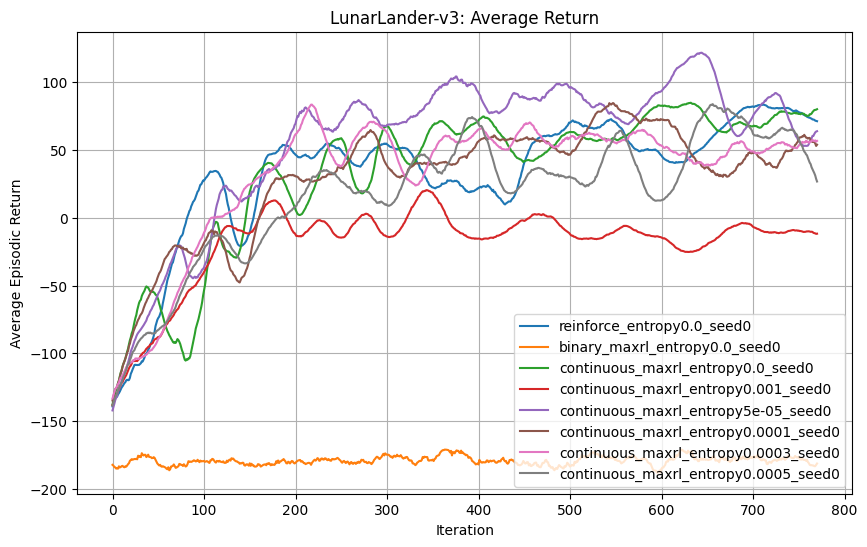

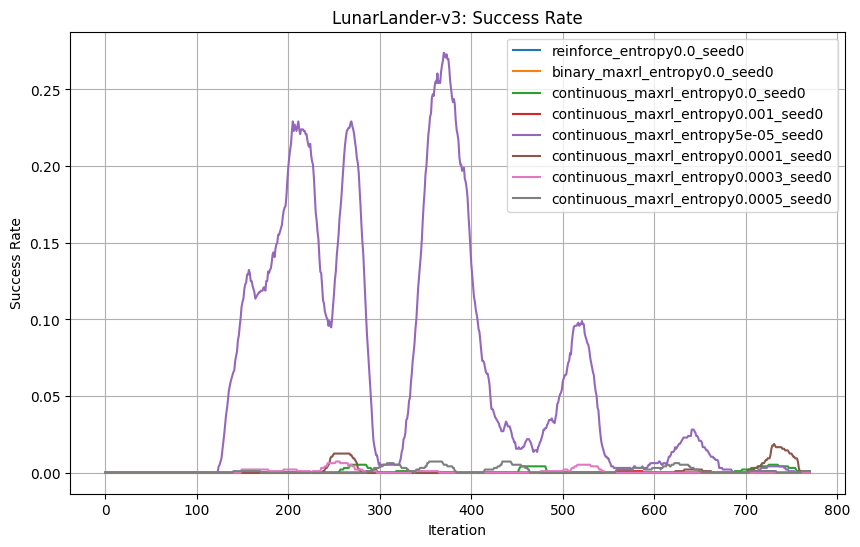

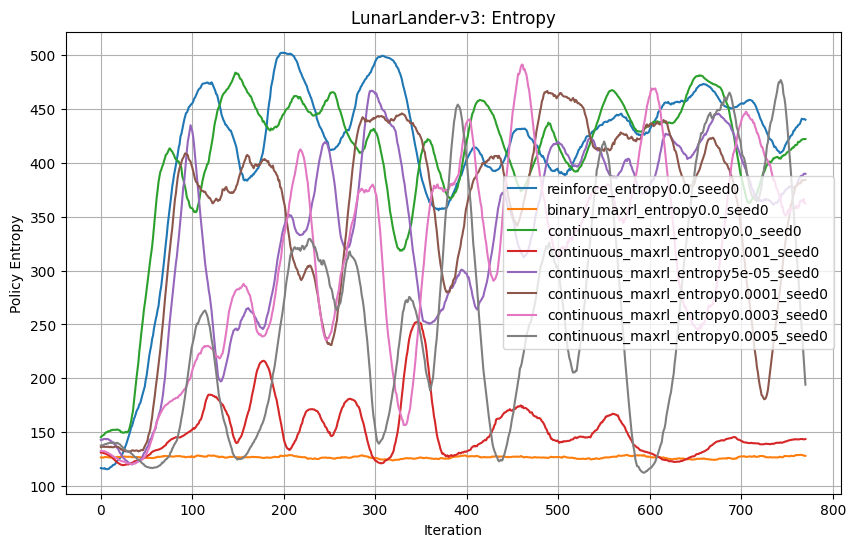

Saved figures to: /content/drive/MyDrive/maxrl_lunar_safe/figures
Recording: entropy_continuous_maxrl_5e-05


/usr/local/lib/python3.12/dist-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /content/drive/MyDrive/maxrl_lunar_safe/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Recording: entropy_continuous_maxrl_0p0001
Recording: entropy_continuous_maxrl_0p0003
Recording: entropy_continuous_maxrl_0p0005
Saved videos to: /content/drive/MyDrive/maxrl_lunar_safe/videos
Created: /content/maxrl_lunar_safe.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [44]:
import os
import glob
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
import gymnasium as gym
from gymnasium.wrappers import RecordVideo

SAVE_ROOT = "/content/drive/MyDrive/maxrl_lunar_safe"
FIG_DIR = os.path.join(SAVE_ROOT, "figures")
VIDEO_DIR = os.path.join(SAVE_ROOT, "videos")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(VIDEO_DIR, exist_ok=True)

def moving_average(x, window=30):
    x = np.asarray(x)
    if len(x) < window:
        return x
    return np.convolve(x, np.ones(window) / window, mode="valid")

# ===============================
# 1. Load saved histories
# ===============================
loaded_histories = {}

for run_dir in glob.glob(os.path.join(SAVE_ROOT, "*")):
    if not os.path.isdir(run_dir):
        continue

    csv_path = os.path.join(run_dir, "history_final.csv")
    if not os.path.exists(csv_path):
        csv_path = os.path.join(run_dir, "history.csv")

    if os.path.exists(csv_path):
        run_name = os.path.basename(run_dir)
        loaded_histories[run_name] = pd.read_csv(csv_path)

print("Loaded runs:")
for k in loaded_histories:
    print(" -", k)

# ===============================
# 2. Plot all loaded results
# ===============================
plt.figure(figsize=(10, 6))
for name, hist in loaded_histories.items():
    y = moving_average(hist["avg_return"], window=30)
    plt.plot(y, label=name)
plt.xlabel("Iteration")
plt.ylabel("Average Episodic Return")
plt.title(f"{ENV_NAME}: Average Return")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, "all_average_return.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
for name, hist in loaded_histories.items():
    y = moving_average(hist["success_rate"], window=30)
    plt.plot(y, label=name)
plt.xlabel("Iteration")
plt.ylabel("Success Rate")
plt.title(f"{ENV_NAME}: Success Rate")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, "all_success_rate.png"), dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
for name, hist in loaded_histories.items():
    if "entropy" in hist.columns:
        y = moving_average(hist["entropy"], window=30)
        plt.plot(y, label=name)
plt.xlabel("Iteration")
plt.ylabel("Policy Entropy")
plt.title(f"{ENV_NAME}: Entropy")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(FIG_DIR, "all_entropy.png"), dpi=300, bbox_inches="tight")
plt.show()

print("Saved figures to:", FIG_DIR)

# ===============================
# 3. Record videos for policies currently in memory
# ===============================
def record_video(env_name, policy, name, max_steps=1000):
    env = gym.make(env_name, render_mode="rgb_array")
    env = RecordVideo(
        env,
        video_folder=VIDEO_DIR,
        name_prefix=name,
        episode_trigger=lambda episode_id: True
    )

    obs, _ = env.reset()
    done = False
    steps = 0

    while not done and steps < max_steps:
        action, _, _ = policy.get_action(obs)
        obs, _, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        steps += 1

    env.close()

if "experiments" in globals():
    for name, obj in experiments.items():
        safe_name = name.replace(" ", "_").lower().replace(".", "p")
        print("Recording:", safe_name)
        record_video(ENV_NAME, obj["policy"], safe_name)
else:
    print("No policies in memory. Videos skipped.")

print("Saved videos to:", VIDEO_DIR)

# ===============================
# 4. Zip everything and download
# ===============================
ZIP_BASE = "/content/maxrl_lunar_safe"
ZIP_PATH = ZIP_BASE + ".zip"

if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)

shutil.make_archive(ZIP_BASE, "zip", SAVE_ROOT)
print("Created:", ZIP_PATH)

files.download(ZIP_PATH)